# BERTopic test for Orange Challenge to extract topics. 
following the tutorial in this webpage: https://medium.com/data-science/topic-modeling-with-bert-779f7db187e6

In [1]:
from bertopic import BERTopic # takes some time to load, not fast
# from sklearn.datasets import fetch_20newsgroups #18000 newsgroup posts on 20 topics
# from sentence_transformers import SentenceTransformer

import pandas as pd
import numpy as np

/home/anna_d/Becode/repos/orange_innovation_challenge/innovation_radar_orange/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(
    "signals.csv",
    sep=",",
    encoding="cp1252"
)
print(df)

      id                                         source_url  \
0      1  https://www.bipt.be/consumers/telephone-intern...   
1      2  https://annual-report.bipt.be/wp-content/uploa...   
2      4  https://digital-strategy.ec.europa.eu/en/misce...   
3      5  https://tecknexus.com/5gusecase/deutsche-telek...   
4      6  https://www.rcrwireless.com/20260212/private-5...   
..   ...                                                ...   
614  657  https://www.berec.europa.eu/en/all-documents/b...   
615  658  https://www.meritalk.com/articles/fedramp-fina...   
616  659  https://axis-intelligence.com/sovereign-cloud-...   
617  660  https://www.proximus.com/news/2026/202605-micr...   
618  661  https://www.datacenterknowledge.com/cloud/ampe...   

                                          source_name  \
0                                         BIPT / IBPT   
1                       BIPT Annual Report 2025 (PDF)   
2    EU Digital Strategy (European Commission portal)   
3              

In [3]:
print(df.shape) # 619, 12 columns (11th is the embedding)
print(df.iloc[0, -1])
print(type(df.iloc[0, -1]))

(619, 12)
regulation
<class 'str'>


In [4]:
import ast # built in package


embeddings = np.array(
    df.iloc[:, -2].apply(ast.literal_eval).tolist(),
    dtype=np.float32
)

# print(embeddings.shape)
# print(embeddings)

In [5]:
print(embeddings.shape) #619, 1536

(619, 1536)


In [6]:
documents = df["summary"].fillna("").tolist()
# class(documents)

In [7]:
# print(df["summary"].dtype)
# print(df["summary"].memory_usage(deep=True) / 1024**2, "MB")

In [8]:
print("Number of documents:", len(df))
print("Number of embeddings:", len(embeddings))
print("Embedding dimensions:", embeddings.shape[1])
print("Data type:", embeddings.dtype)
print("Any NaN:", np.isnan(embeddings).any())

Number of documents: 619
Number of embeddings: 619
Embedding dimensions: 1536
Data type: float32
Any NaN: False


In [9]:
# run bertopic

topic_model = BERTopic(
    min_topic_size=10,
    verbose=True
)

topics, probabilities = topic_model.fit_transform(
    documents,
    embeddings
)

2026-08-26 21:53:30,861 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-26 21:53:44,203 - BERTopic - Dimensionality - Completed ✓
2026-08-26 21:53:44,204 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-26 21:53:44,223 - BERTopic - Cluster - Completed ✓
2026-08-26 21:53:44,227 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-26 21:53:44,263 - BERTopic - Representation - Completed ✓


In [10]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,46,-1_and_to_the_for,"[and, to, the, for, vodafone, network, operato...",[BEREC’s 2024 draft report examines the interp...
1,0,64,0_security_sase_fabrics_vendors,"[security, sase, fabrics, vendors, and, palo, ...",[Palo Alto highlights its continued SASE and S...
2,1,48,1_verizons_verizon_mec_and,"[verizons, verizon, mec, and, edge, enterprise...",[Verizon’s 5G Edge product pages and white pap...
3,2,46,2_private_operators_and_5g,"[private, operators, and, 5g, networks, deploy...",[GSMA's collection of private network case stu...
4,3,45,3_cloud_ai_sovereign_industrial,"[cloud, ai, sovereign, industrial, deutsche, a...",[Deutsche Telekom and NVIDIA launched the Indu...
5,4,39,4_telefnicas_telefnica_and_edge,"[telefnicas, telefnica, and, edge, in, network...",[Telefónica Tech was named a Leader in Gartner...
6,5,36,5_atts_att_ai_and,"[atts, att, ai, and, to, private, fiber, the, ...",[RCR Wireless analyses AT&T’s Connected AI ini...
7,6,35,6_regulatory_and_for_bipt,"[regulatory, and, for, bipt, the, regulator, p...",[Belgian regulator BIPT published a dispute wh...
8,7,31,7_vodafone_vodafones_cloud_services,"[vodafone, vodafones, cloud, services, to, sov...",[Vodafone announced a ten-year strategic deal ...
9,8,27,8_capacity_cable_subsea_routes,"[capacity, cable, subsea, routes, carriers, ow...",[BeBeez covers MDM's announcement of a new tra...


In [11]:
for topic in topic_model.get_topics():
    if topic != -1:
        print(f"\nTopic {topic}:")
        print(topic_model.get_topic(topic))


Topic 0:
[('security', np.float64(0.09561773982893866)), ('sase', np.float64(0.05946677220615214)), ('fabrics', np.float64(0.029281005841784457)), ('vendors', np.float64(0.028880557709288664)), ('and', np.float64(0.028704315070467643)), ('palo', np.float64(0.02786186649357201)), ('fabric', np.float64(0.027586124718069795)), ('alto', np.float64(0.026865974752151606)), ('unified', np.float64(0.026386727991197196)), ('carrier', np.float64(0.025293533076508976))]

Topic 1:
[('verizons', np.float64(0.07149647829257326)), ('verizon', np.float64(0.05182903289583513)), ('mec', np.float64(0.03594567390295392)), ('and', np.float64(0.03536529039032297)), ('edge', np.float64(0.03414398203271591)), ('enterprise', np.float64(0.0288348380842385)), ('to', np.float64(0.028296608861846123)), ('for', np.float64(0.02793297048316079)), ('private', np.float64(0.02770594736859802)), ('5g', np.float64(0.02733252436064874))]

Topic 2:
[('private', np.float64(0.0560694342710382)), ('operators', np.float64(0.03

In [12]:
print(topic_model.get_topic_info())

    Topic  Count                                    Name  \
0      -1     46                       -1_and_to_the_for   
1       0     64         0_security_sase_fabrics_vendors   
2       1     48              1_verizons_verizon_mec_and   
3       2     46              2_private_operators_and_5g   
4       3     45         3_cloud_ai_sovereign_industrial   
5       4     39         4_telefnicas_telefnica_and_edge   
6       5     36                       5_atts_att_ai_and   
7       6     35               6_regulatory_and_for_bipt   
8       7     31     7_vodafone_vodafones_cloud_services   
9       8     27          8_capacity_cable_subsea_routes   
10      9     26      9_telefnica_cloud_google_sovereign   
11     10     24            10_proximus_5g_and_proximuss   
12     11     23                   11_dts_5g_deutsche_in   
13     12     23                   12_lumens_lumen_to_ai   
14     13     22          13_regulatory_and_cloud_ofcoms   
15     14     21                 14_oper

In [13]:
# from the github
# from bertopic.representation import KeyBERTInspired

# # Fine-tune your topic representations
# representation_model = KeyBERTInspired()
# topic_model = BERTopic(representation_model=representation_model)

# topics, probabilities = topic_model.fit_transform(
#     documents,
#     embeddings
# )

In [14]:
topic_model.visualize_topics()

In [15]:
# embedding_col = df.columns[-1]

# embeddings = np.array(
#     df[embedding_col].apply(
#         lambda x: np.fromstring(x.strip("[]"), sep=",")
#     ).tolist()
# )

# documents = df["summary"].fillna("").tolist()

In [16]:
from umap import UMAP

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

In [17]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
)

topics, probabilities = topic_model.fit_transform(
    documents,
    embeddings=embeddings
)

2026-08-26 21:53:43,056 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-26 21:53:44,702 - BERTopic - Dimensionality - Completed ✓
2026-08-26 21:53:44,703 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-26 21:53:44,719 - BERTopic - Cluster - Completed ✓
2026-08-26 21:53:44,723 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-26 21:53:44,776 - BERTopic - Representation - Completed ✓


(619, 2)


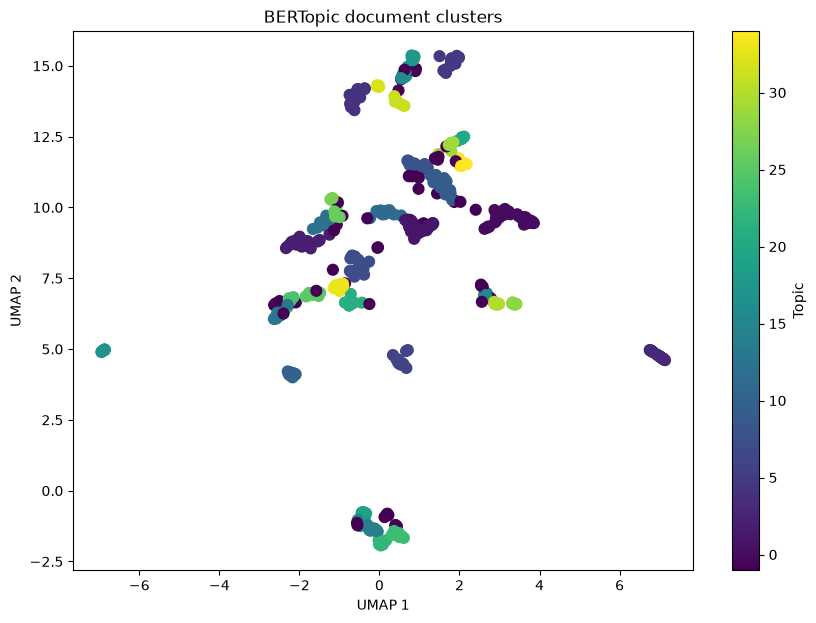

In [18]:
umap_2d = UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

embedding_2d = umap_2d.fit_transform(embeddings)

print(embedding_2d.shape)

df["umap_x"] = embedding_2d[:, 0]
df["umap_y"] = embedding_2d[:, 1]
df["topic"] = topics

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df["umap_x"],
    df["umap_y"],
    c=df["topic"],
    s=60
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("BERTopic document clusters")
plt.colorbar(scatter, label="Topic")

plt.show()

In [19]:
topic_model.visualize_documents(
    documents,
    embeddings=embeddings
)

/home/anna_d/Becode/repos/orange_innovation_challenge/innovation_radar_orange/.venv/lib/python3.12/site-packages/bertopic/plotting/_documents.py:166: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selection["text"] = ""
/home/anna_d/Becode/repos/orange_innovation_challenge/innovation_radar_orange/.venv/lib/python3.12/site-packages/bertopic/plotting/_documents.py:167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selection.loc[len(selection), :] = [
/home/anna_d/Becode/repos/orange_innovation_challenge/innovation_radar_orange/.venv/lib/python3.12/site-packages/bert

In [20]:
topic_model.visualize_hierarchy()

In [21]:
# Save original representations
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [22]:
def topic_differences(model, original_topics, nr_topics=5):
    """Show the differences in topic representations between two
    models"""
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):
        # Extract top 5 words per topic per model
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        df.loc[len(df)] = [topic, og_words, new_words]
    return df

In [23]:
# from bertopic.representation import KeyBERTInspired
# # Update our topic representations using KeyBERTInspired
# representation_model = KeyBERTInspired()
# topic_model.update_topics(documents, representation_model=representation_model)

In [24]:
from bertopic.representation import MaximalMarginalRelevance

representation_model = MaximalMarginalRelevance(diversity=0.3)
topic_model.update_topics(documents, representation_model=representation_model)

In [25]:
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,verizons | verizon | mec | edge | and,verizons | verizon | mec | edge | and
1,1,vodafone | vodafones | iot | cloud | sovereign,vodafone | vodafones | iot | cloud | sovereign
2,2,telefnica | cloud | google | regulated | tech,telefnica | cloud | google | regulated | tech
3,3,capacity | cable | subsea | routes | ownership,capacity | cable | subsea | routes | ownership
4,4,regulatory | ofcoms | cloud | and | providers,regulatory | ofcoms | cloud | and | providers


In [ ]:
# 1. Imports
from transformers import pipeline
from bertopic.representation import BaseRepresentation


# 2. Custom representation class (fixes chat-formatting issue)
class ChatTextGeneration(BaseRepresentation):
    def __init__(self, model_name="Qwen/Qwen2.5-0.5B-Instruct", prompt=None, doc_length=50, max_new_tokens=40):
        self.generator = pipeline("text-generation", model=model_name)
        self.tokenizer = self.generator.tokenizer
        self.prompt = prompt
        self.doc_length = doc_length
        self.max_new_tokens = max_new_tokens

    def extract_topics(self, topic_model, documents, c_tf_idf, topics):
        updated_topics = {}

        for topic, topic_words in topics.items():
            keywords = ", ".join([word for word, _ in topic_words])

            # Grab a few example docs for this topic
            topic_docs = documents.loc[documents.Topic == topic, "Document"].tolist()[:4]
            docs_text = "\n".join([doc[: self.doc_length] for doc in topic_docs])

            filled_prompt = self.prompt.replace("[KEYWORDS]", keywords).replace("[DOCUMENTS]", docs_text)

            # Chat format instead of plain string -- this is the actual fix
            messages = [{"role": "user", "content": filled_prompt}]

            output = self.generator(
                messages,
                max_new_tokens=self.max_new_tokens,
                do_sample=False,
            )

            generated_text = output[0]["generated_text"][-1]["content"].strip()

            # Clean up common unwanted prefix, just in case
            for prefix in ["This topic is about", "this topic is about", "The topic is about", "the topic is about"]:
                generated_text = generated_text.removeprefix(prefix).strip()

            updated_topics[topic] = [(generated_text, 1)]

        return updated_topics


# 3. Your prompt
prompt = """I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: '[KEYWORDS]'.
Based on the documents and keywords, write a headline with maximum 30 characters what is the topic about.
Do not start the sentence with 'the topic is about'. Directly write the content."""


# 4. Create the representation model
representation_model = ChatTextGeneration(
    model_name="Qwen/Qwen2.5-0.5B-Instruct",
    prompt=prompt,
    doc_length=50,
    max_new_tokens=40,
)


# 5. Apply it to your existing topic model
topic_model.update_topics(documents, representation_model=representation_model)


# 6. Check the result
topic_model.get_topic_info()

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 1267.43it/s]
[transformers] Both `max_new_tokens` (=40) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,62,-1_Vodafone's MEC offering enhances connectivi...,-1_ The topic is about a collaboration between...,[Vodafone's MEC offering enhances connectivity...,[Gartner Peer Insights compares Deutsche Telek...
1,0,48,"0_Verizon expands alliance with Ericsson, comb...",0_ \n1. Verizon's Managed Private MEC and 5G S...,"[Verizon expands alliance with Ericsson, combi...",[Verizon’s 5G Edge product pages and white pap...
2,1,32,1_Vodafone's FY26 annual report details strate...,1_ This topic is about Vodafone promoting a fe...,[Vodafone's FY26 annual report details strateg...,[Independent telecom press covered Vodafone's ...
3,2,27,2_Telefonica renewed and extended its partners...,"2_ **Telefonica, Google Cloud, and Sovereign C...",[Telefonica renewed and extended its partnersh...,[Tech press coverage explains the Telefónica–G...
4,3,27,3_TeleGeography warns of falling capacity in t...,3_ This topic is about the developments in sub...,[TeleGeography warns of falling capacity in tr...,[BeBeez covers MDM's announcement of a new tra...
5,4,24,4_Ofcom's Regulatory Framework for Connected N...,4_ This topic is about the regulatory focus on...,[Ofcom's Regulatory Framework for Connected Na...,[BEREC published its 2026–2030 strategy that e...
6,5,24,"5_Proximus launches 5G+ across Belgium, enabli...",5_ Proximus announces the commercial launch of...,"[Proximus launches 5G+ across Belgium, enablin...",[Independent reporting on Proximus’s commercia...
7,6,23,6_Equinix announces expanded collaborations wi...,6_ Lumen announces strategic alliance with Mic...,[Equinix announces expanded collaborations wit...,[Lumen announced a partnership with AWS to enh...
8,7,22,7_MWL's 2026 industry survey explores AI-drive...,7_ This topic is about the integration of arti...,[MWL's 2026 industry survey explores AI-driven...,[DatacenterDynamics covers Orange’s choice to ...
9,8,20,"8_Private networks, spectrum management, and d...","8_ This topic is about private networks, their...","[Private networks, spectrum management, and de...",[GSMA's whitepaper provides architecture patte...


In [47]:
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,verizons | verizon | mec | edge | and,"Verizon expands alliance with Ericsson, combin..."
1,1,vodafone | vodafones | iot | cloud | sovereign,Vodafone's FY26 annual report details strategi...
2,2,telefnica | cloud | google | regulated | tech,Telefonica renewed and extended its partnershi...
3,3,capacity | cable | subsea | routes | ownership,TeleGeography warns of falling capacity in tra...
4,4,regulatory | ofcoms | cloud | and | providers,Ofcom's Regulatory Framework for Connected Nat...


In [48]:
import datamapplot
import bertopic.plotting as plotting

plotting.datamapplot = datamapplot

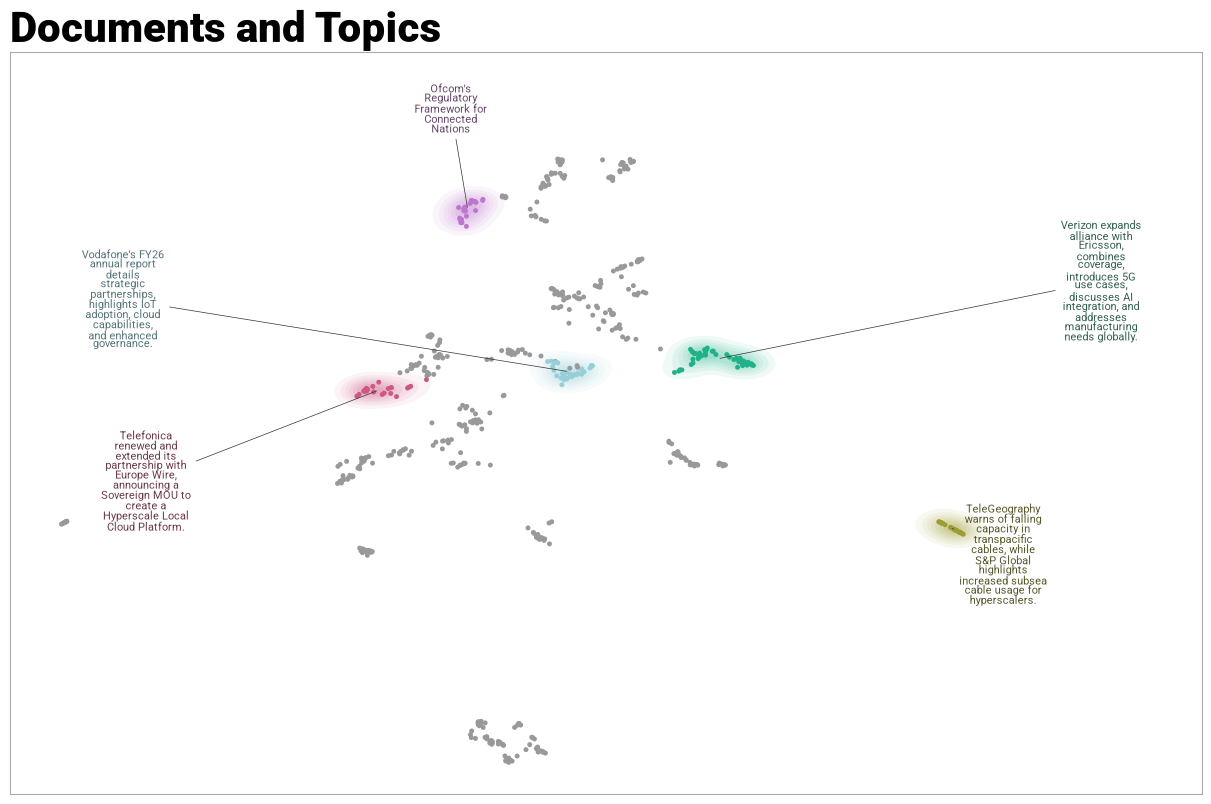

In [49]:
fig = topic_model.visualize_document_datamap(
    topics=list(range(5)),
    reduced_embeddings=embedding_2d,
    width=1200,
)

In [50]:
import sys
import bertopic
import datamapplot

print("Python:", sys.executable)
print("BERTopic:", bertopic.__version__)
print("DataMapPlot:", datamapplot.__version__)
print("DataMapPlot location:", datamapplot.__file__)

Python: /home/anna_d/Becode/repos/orange_innovation_challenge/innovation_radar_orange/.venv/bin/python
BERTopic: 0.17.4
DataMapPlot: 0.7.3
DataMapPlot location: /home/anna_d/Becode/repos/orange_innovation_challenge/innovation_radar_orange/.venv/lib/python3.12/site-packages/datamapplot/__init__.py


Calculating medoids: 100%|██████████| 5/5 [00:00<00:00,  6.03it/s]


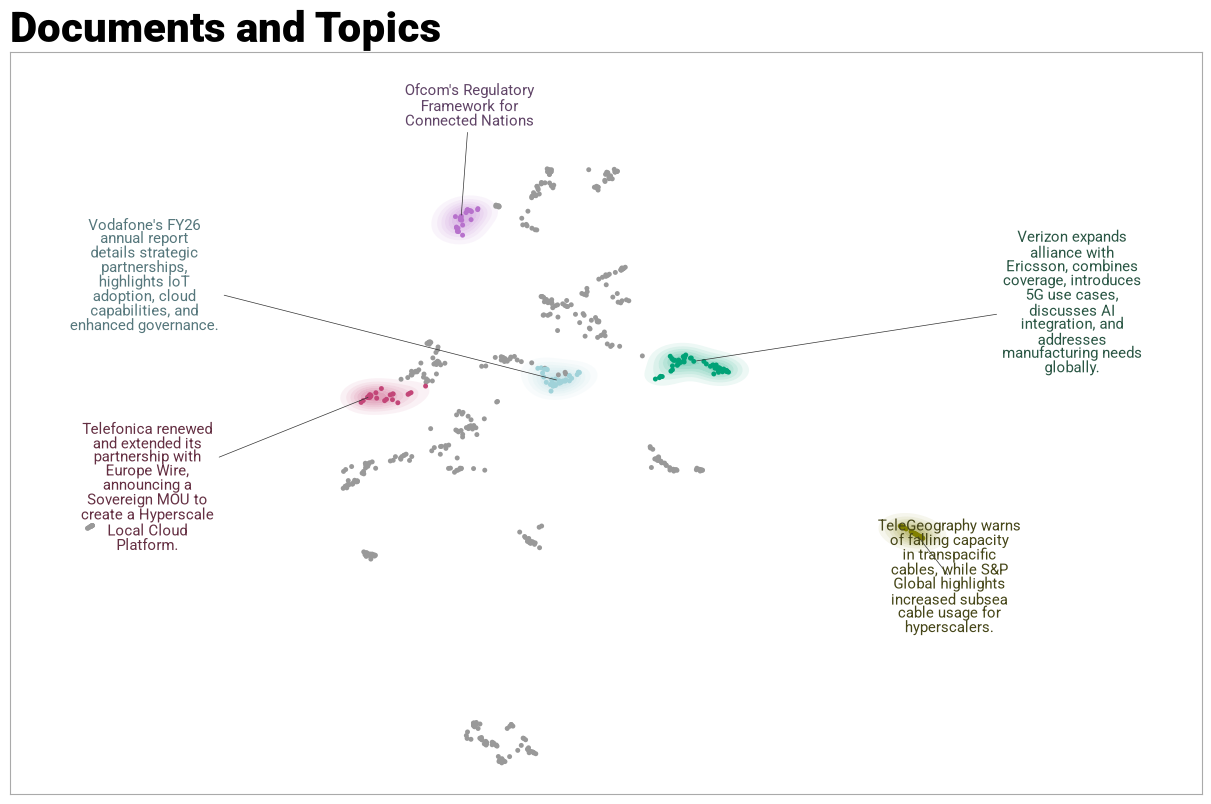

In [51]:
# Visualize topics and documents
# fig = topic_model.visualize_document_datamap(
# #titles,
# topics=list(range(20)),
# reduced_embeddings=embedding_2d,
# width=1200,
# label_font_size=11,
# label_wrap_width=20,
# use_medoids=True,
# )
import datamapplot

fig = topic_model.visualize_document_datamap(
    topics=list(range(5)),
    reduced_embeddings=embedding_2d,
    width=1200,
    datamap_kwds={
        "label_font_size": 11,
        "label_wrap_width": 20,
        "use_medoids": True,
    },
)

Calculating medoids: 100%|██████████| 25/25 [00:00<00:00, 32.50it/s]


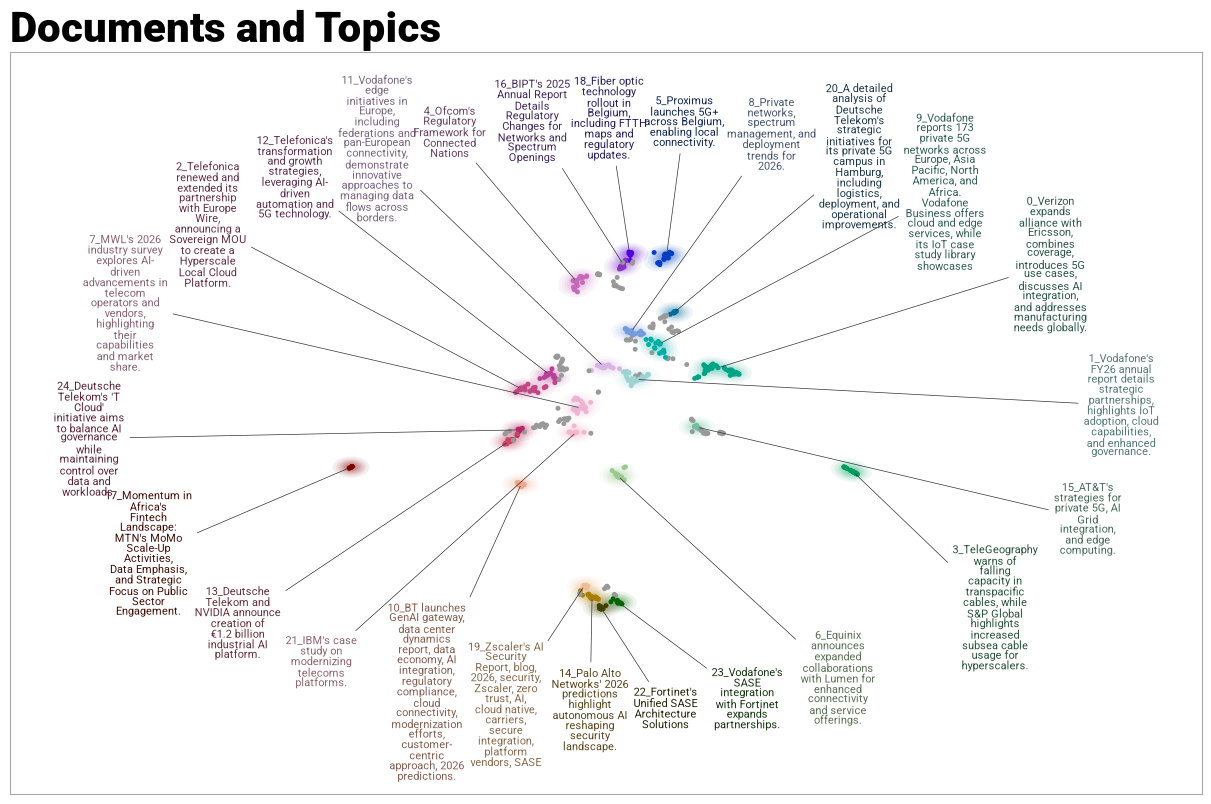

In [55]:
topic_info = topic_model.get_topic_info()

custom_labels = {
    row.Topic: (row.Name[0:200]) if len(row.Name) > 40 else row.Name
    for row in topic_info.itertuples()
}

topic_model.set_topic_labels(custom_labels)

fig = topic_model.visualize_document_datamap(
    topics=list(range(25)),
    reduced_embeddings=embedding_2d,
    width=1200,
    custom_labels=True,
    datamap_kwds={
        "label_font_size": 8,
        "label_wrap_width": 15,
        "use_medoids": True,
    },
)

In [ ]:
# fig.savefig("innovation_radar_orange/topic_datamap.png", dpi=300, bbox_inches="tight")